# Benchmarking MLPs
A template to plot qunatities useful to evaluate and benchmark a MLP. Files should be produced by running the benchmark.py script. 

Check out test sets!

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
import math

In [69]:
#define some plotting functions
def plot_values_vs_rel_error(filenames, datalabels=None, figsize=(6,4), ylim=(-10,10), dpi=150):
    x = []  # rel_error
    y = []  # corresponding value
    labels = ["lattice constant", "cohesive energy", "bulk modulus", 
              "(111) surface energy", "(110) surface energy","(100) surface energy"]

    if datalabels is None:
        datalabels=filenames

    plt.figure(dpi=dpi, figsize=figsize)

    x = np.arange(len(labels))
    plt.hlines(0,  min(x), max(x), linestyles='--', color='k', lw=0.8)

    # Collect all datasets first so we can order them by their total (sum)
    datasets = []  # list of tuples (sum, y_array, label)
    for fname, lab in zip(filenames, datalabels):
        with open(fname, "r") as f:
            data = yaml.safe_load(f)

        g111 = data["fcc111"]["rel_error"]
        g110 = data["fcc110"]["rel_error"]
        g100 = data["fcc100"]["rel_error"]
        a0   = data["fcc_bulk"]["a0_rel_error"]
        e0   = data["fcc_bulk"]["e0_rel_error"]
        B    = data["fcc_bulk"]["B_rel_error"]

        y_vals = np.array([a0, e0, B, g111, g110, g100], dtype=float)
        weights = np.array([1, 1, 0.33, 1, 1, 1], dtype=float)
        total = np.sum(weights * np.abs(y_vals))

        datasets.append((total, y_vals, lab))

    # Sort datasets by total sum. Assumption: sort descending so highest totals appear first.
    datasets.sort(key=lambda t: t[0], reverse=True)

    # Prepare colormap mapping. We want "cool" colors (blue) for high totals and warm (red) for low totals.
    totals = np.array([t[0] for t in datasets])
    if totals.max() > totals.min():
        norm = (totals - totals.min()) / (totals.max() - totals.min())
    else:
        norm = np.zeros_like(totals)
    # invert so high totals -> small values -> blue in 'coolwarm'
    color_vals = 1.0 - norm
    cmap = plt.get_cmap('coolwarm')

    
    # Plot in sorted order with constant colors per line
    for (tot, y_vals, lab), cv in zip(datasets, color_vals):
        plt.plot(x, y_vals, label=lab, marker='s', color=cmap(cv))

    plt.xlabel("")
    plt.xticks(x, labels, rotation=90.)
    plt.ylabel("absolute error wrt DFT (%)")
    plt.legend(fontsize=6, ncol=1, columnspacing=0.8, handlelength=1.5, loc='lower left')
    plt.tight_layout()
    if ylim is not None:
        plt.ylim(ylim)
    #plt.ylim(0,10)
    #plt.show()

def plot_ref_clusters_energies(filenames, datalabels=None, figsize=(6,4), ylim=(-1,1), dpi=150):
    x = []  # rel_error
    y = []  # corresponding value
    labels = ["ih55.xyz", "ih147.xyz", "dh55.xyz", "dh147.xyz", "oh55.xyz", "oh147.xyz"]

    if datalabels is None:
        datalabels=filenames

    plt.figure(dpi=dpi, figsize=figsize)

    x = np.arange(len(labels))
    plt.hlines(0,  min(x), max(x), linestyles='--', color='k', lw=0.8)

    # Collect all datasets first so we can order them by their total (sum)
    datasets = []  # list of tuples (sum, y_array, label)
    for fname, lab in zip(filenames, datalabels):
        with open(fname, "r") as f:
            data = yaml.safe_load(f)

        y_vals = [data['special_configs'][l]['perc_diff'] for l in labels]

        weights = np.array([1]*len(labels), dtype=float)
        total = np.sum(weights * np.abs(y_vals))

        datasets.append((total, y_vals, lab))

    # Sort datasets by total sum. Assumption: sort descending so highest totals appear first.
    datasets.sort(key=lambda t: t[0], reverse=True)

    # Prepare colormap mapping. We want "cool" colors (blue) for high totals and warm (red) for low totals.
    totals = np.array([t[0] for t in datasets])
    if totals.max() > totals.min():
        norm = (totals - totals.min()) / (totals.max() - totals.min())
    else:
        norm = np.zeros_like(totals)
    # invert so high totals -> small values -> blue in 'coolwarm'
    color_vals = 1.0 - norm
    cmap = plt.get_cmap('coolwarm')

    
    # Plot in sorted order with constant colors per line
    for (tot, y_vals, lab), cv in zip(datasets, color_vals):
        plt.plot(x, y_vals, label=lab, marker='s', color=cmap(cv))

    xlabels = [l.strip('.xyz') for l in labels]

    plt.xlabel("")
    plt.xticks(x, xlabels, rotation=90.)
    plt.ylabel("absolute error wrt DFT energy (%)")
    plt.legend(fontsize=6, ncol=1, columnspacing=0.8, handlelength=1.5, loc='lower left')
    plt.tight_layout()
    if ylim is not None:
        plt.ylim(ylim)
    #plt.ylim(0,10)
    #plt.show()

def plot_parity_with_yaml(folders, benchmark_yaml_files, test_set_file, titles=None, dpi=200, figsize=(5.0,7.4)):
    """
    Generate 3xN parity plots (Energy, Forces, Stress) for multiple (N) test sets,
    with MAE/MAV read from YAML files.

    Parameters
    ----------
    folders : list of str
        Paths to folders containing 'e-parity.dat', 'f-parity.dat', 's-parity.dat'.
    benchmark_yaml_files : list of str
        YAML files corresponding to each folder, containing mae/mav values.
    titles : list of str, optional
        Titles for each folder/column.
    dpi : int
        Figure DPI.
    figsize : tuple
        Figure size.
    """

    fig, axs = plt.subplots( len(folders), 3, dpi=dpi, figsize=figsize, sharex='col')

    parity_labels = ['E/at [eV]', '|F| (eV/A)', '|σ| [eV/A^3]']
    parity_colors = ['r', 'g', 'b']
    keys = ['e', 'f', 's']

    for i, fol in enumerate(folders):
        # Load parity data
        e_parity = np.loadtxt(fol+f'_{test_set_file}_e-parity.dat')
        f_parity = np.loadtxt(fol+f'_{test_set_file}_f-parity.dat')
        s_parity = np.loadtxt(fol+f'_{test_set_file}_s-parity.dat')
        parity_data = [e_parity, f_parity, s_parity]

        # Load MAE/MAV from YAML if provided

        with open(benchmark_yaml_files[i], 'r') as f:
            ydata = yaml.safe_load(f)
        mae_e = ydata.get(test_set_file, {}).get("energy_per_atom", {}).get("mae", np.nan)
        mae_f = ydata.get(test_set_file, {}).get("forces", {}).get("mae", np.nan)
        mae_s = ydata.get(test_set_file, {}).get("stress", {}).get("mae", np.nan)
        mav_e = ydata.get(test_set_file, {}).get("energy_per_atom", {}).get("mav", np.nan)
        mav_f = ydata.get(test_set_file, {}).get("forces", {}).get("mav", np.nan)
        mav_s = ydata.get(test_set_file, {}).get("stress", {}).get("mav", np.nan)

        # map YAML values to the parity keys so each plot shows the correct physical MAE/MAV
        yaml_values = {
            'e': {'mae': mae_e, 'mav': mav_e, 'unit': 'eV/at',   'name': 'Energy'},
            'f': {'mae': mae_f, 'mav': mav_f, 'unit': 'eV/Å',    'name': 'Force (|F|)'},
            's': {'mae': mae_s, 'mav': mav_s, 'unit': 'eV/Å^3',  'name': 'Stress (|σ|)'}
        }

        if (len(folders)==1):
            this_axs = axs
        else:
            this_axs = axs[i,:]


        for ax, data, label, c, k in zip(this_axs, parity_data, parity_labels, parity_colors, keys):
            ax.plot(data[:,0], data[:,0], 'k--')        # parity line
            ax.plot(data[:,0], data[:,1], 'o', color=c) # predicted vs DFT
            ax.set_xlabel('DFT ' + label)
            ax.set_ylabel('MLP ' + label)

            # Add MAE/MAV from YAML (use the corresponding physical quantity)
            mae = yaml_values.get(k, {}).get('mae', np.nan)
            mav = yaml_values.get(k, {}).get('mav', np.nan)
            unit = yaml_values.get(k, {}).get('unit', '')
            name = yaml_values.get(k, {}).get('name', label)

            if np.isnan(mae):
                ann = f"MAE : n/a"
            else:
                pct = 100. * mae / mav if (mav and not np.isnan(mav)) else np.nan
                pct_str = f"{pct:.2g}%" if not np.isnan(pct) else "n/a"
                ann = f"MAE : {mae:.2g} {unit} ({pct_str})"

            ax.text(0.05, 0.95, ann,
                    transform=ax.transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        if titles:
            axs[i,0].set_title(titles[i])

    plt.tight_layout()
    #plt.show()


In [70]:
#choose files
folders_r = [f'random/{i*2+1}/' for i in range(21)]
folders_i = [f'injected/{i*2+1}/' for i in range(21)]
folders_o = [f'ordered/{i*2+1}/' for i in range(21)]

full_names_r = [f+'flare_lammps_benchmark.yaml' for f in folders_r]
full_names_i = [f+'flare_lammps_benchmark.yaml' for f in folders_i]
full_names_o = [f+'flare_lammps_benchmark.yaml' for f in folders_o]

## Accuracy with respect to DFT values

Here we plot the absolute error of our model(s) with respect to the ab-inito reference (Density Functional Theory, DFT) as a percentage
$$
err=\frac{|A^{DFT}-A^{model}|}{A^{model}}
$$
where $A$ is a generic derived quantity. Here we consider FCC lattice constant, cohesive energy, bulk modulus, and surface energy of the three low Miller indexes FCC surfaces.

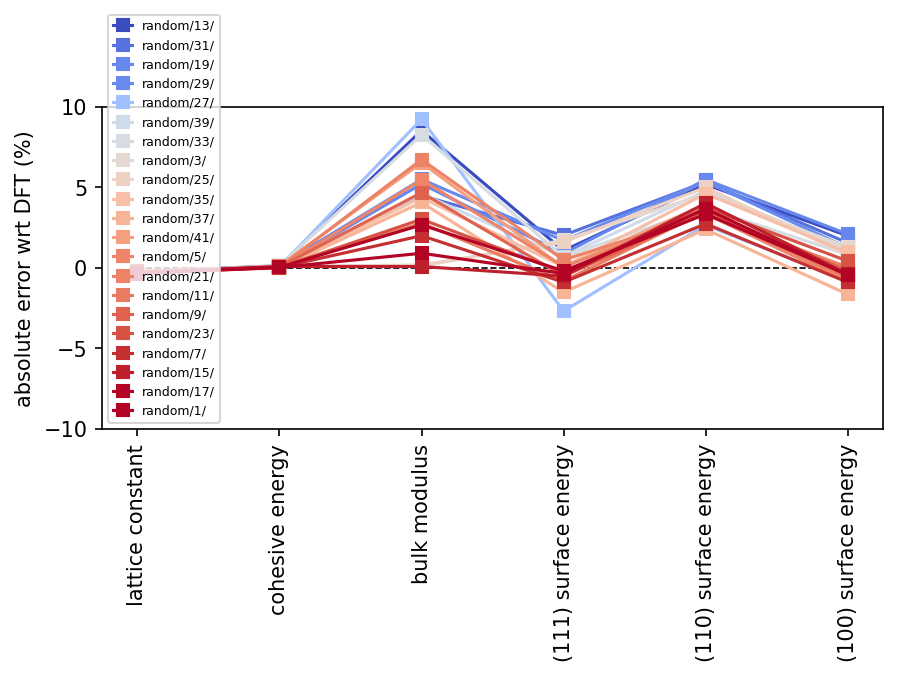

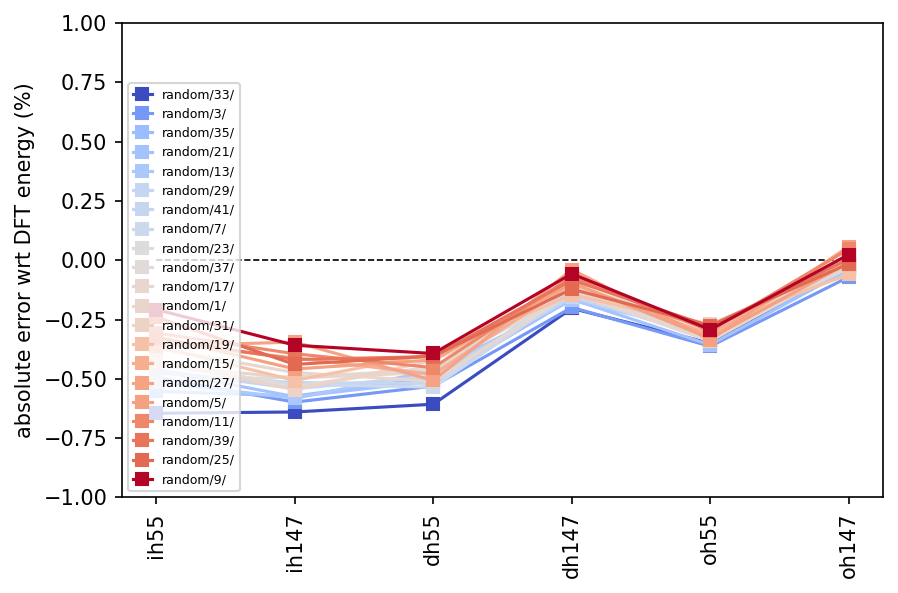

In [21]:
plot_values_vs_rel_error(full_names_r, datalabels=folders_r, figsize=(6,4))
plot_ref_clusters_energies(full_names_r, datalabels=folders_r)

## Parity plots

Parity plots for energy forces, and stresses in a test set (ML model vs ab-initio reference). Also reported are the mean absolute errors (MAE) and, in brackets, the mean absolute error/mean absolute value ratio, in percentage points. An ideal model returns exactly the reference values, thus, points would lie on the black dotted line in this case (corresponding to y=x).

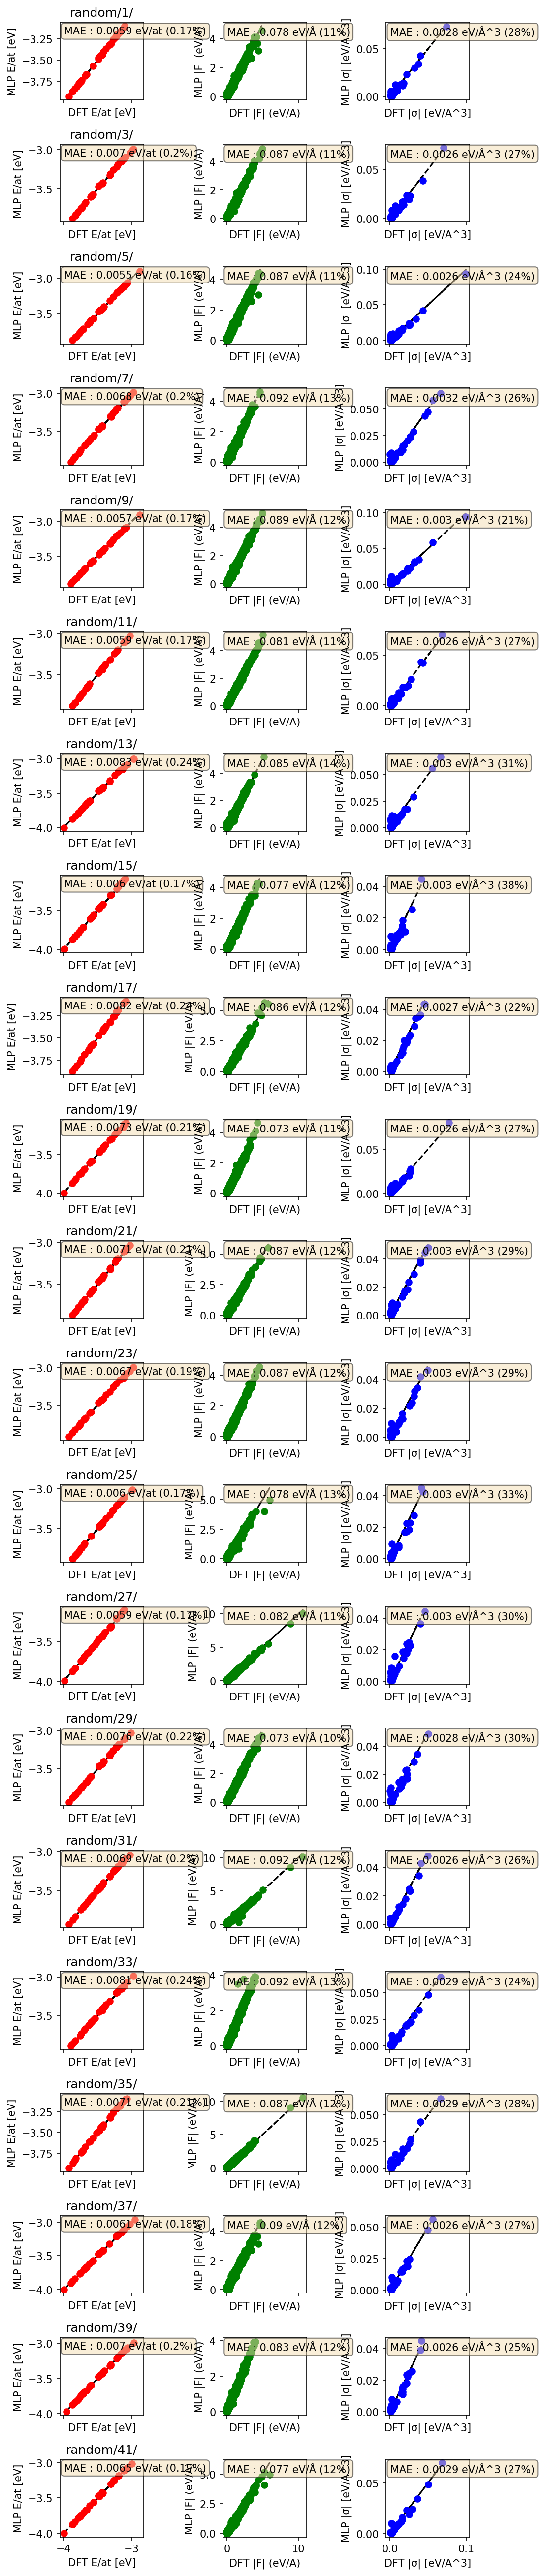

In [72]:
plot_parity_with_yaml(folders_r, full_names_r, test_set_file='test.xyz', titles=folders_r, figsize=(7, 35), dpi=150)

## Far-atom plots

Plots from systems where an atom is far away from other atoms - often an undersampled region of the configuration space, where the potential can give off unphysical results due to being in a hard extrapolation regime. Here plotting atom distance VS energy curves for a dimer, an atom above a (111) FCC surface, and a FCC lattice over a large range of lattice constants.


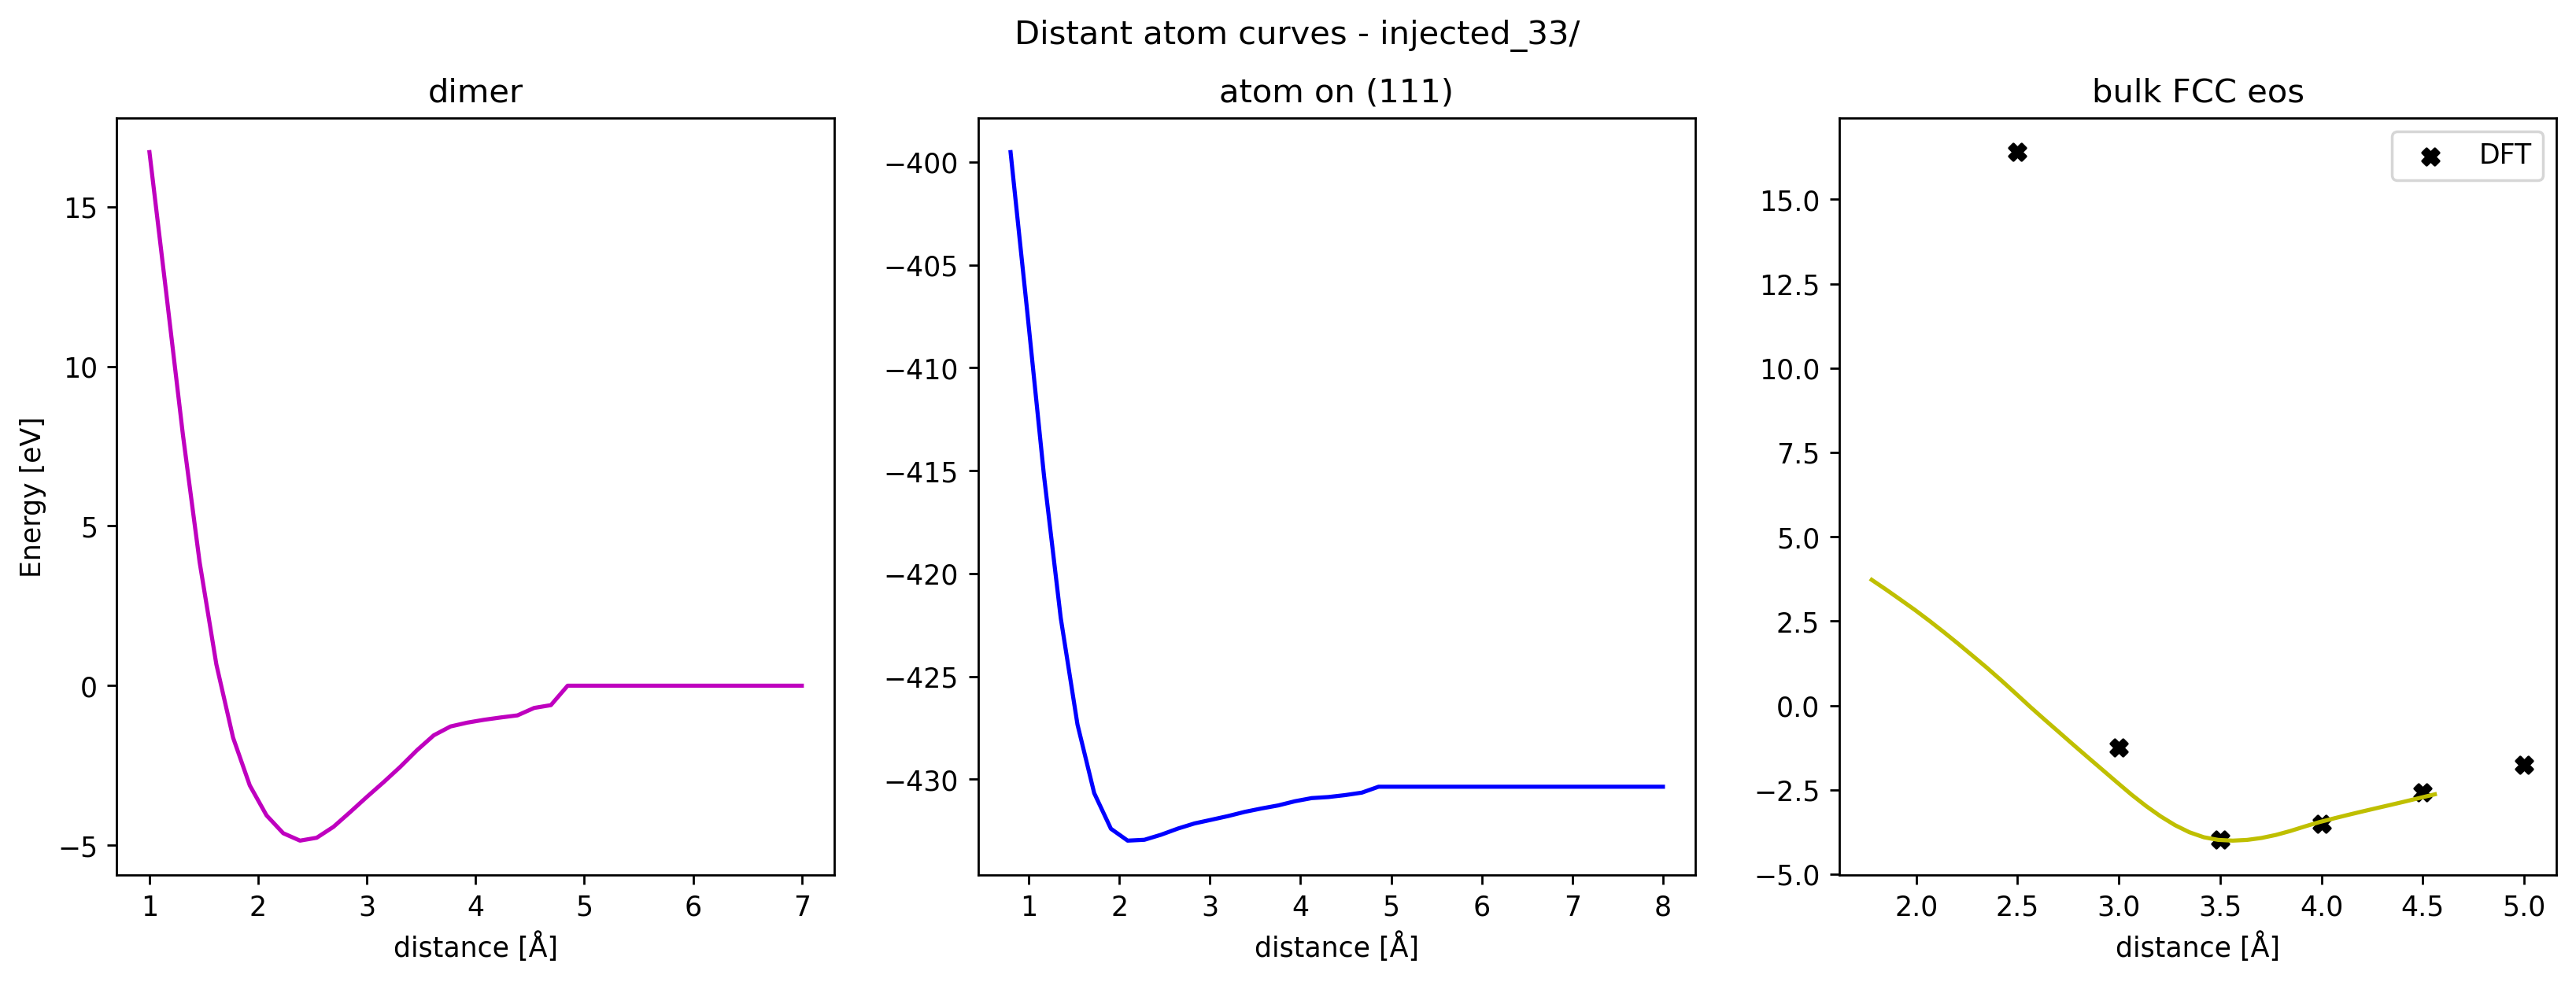

In [17]:
#plot far-atom energy curves
eos_large_ref = np.asarray([
    #[2.0, -1558.0512495920227],
    [2.5, -1645.04309947047],
    [3.0, -1662.685092877471],
    [3.5, -1665.4185483608774],
    [4.0, -1664.9515881903797],
    [4.5, -1664.0270273409217],
    [5.0, -1663.2001708360156]
])
E_iso = -1661.4439420703893


for fol, lab in zip(folders, folders):
    files  = [fol+'dimer_curve.dat', fol+'adsorbate_curve.dat', fol+'large_eos_curve.dat']
    colors = ['m', 'b', 'y']
    titles = ['dimer', 'atom on (111)', 'bulk FCC eos']
    fig, axs = plt.subplots(1, len(files), figsize = (16,5), dpi=250)

    for f, a, c, t in zip(files, axs, colors, titles):
        data = np.loadtxt(f)
        if f==fol+'large_eos_curve.dat':
            data[:,1] = data[:,1]/4 #4 atoms per conv. cell
        a.plot(data[:,0], data[:,1], color=c)
        if f==fol+'large_eos_curve.dat':
            a.scatter(eos_large_ref[:,0], eos_large_ref[:,1]-E_iso, marker='X', color='k', label='DFT')    
            a.legend()
        a.set_xlabel('distance [Å]')
        a.set_title(t)

    axs[0].set_ylabel('Energy [eV]')
    plt.suptitle(f'Distant atom curves - {lab}')
    plt.show()

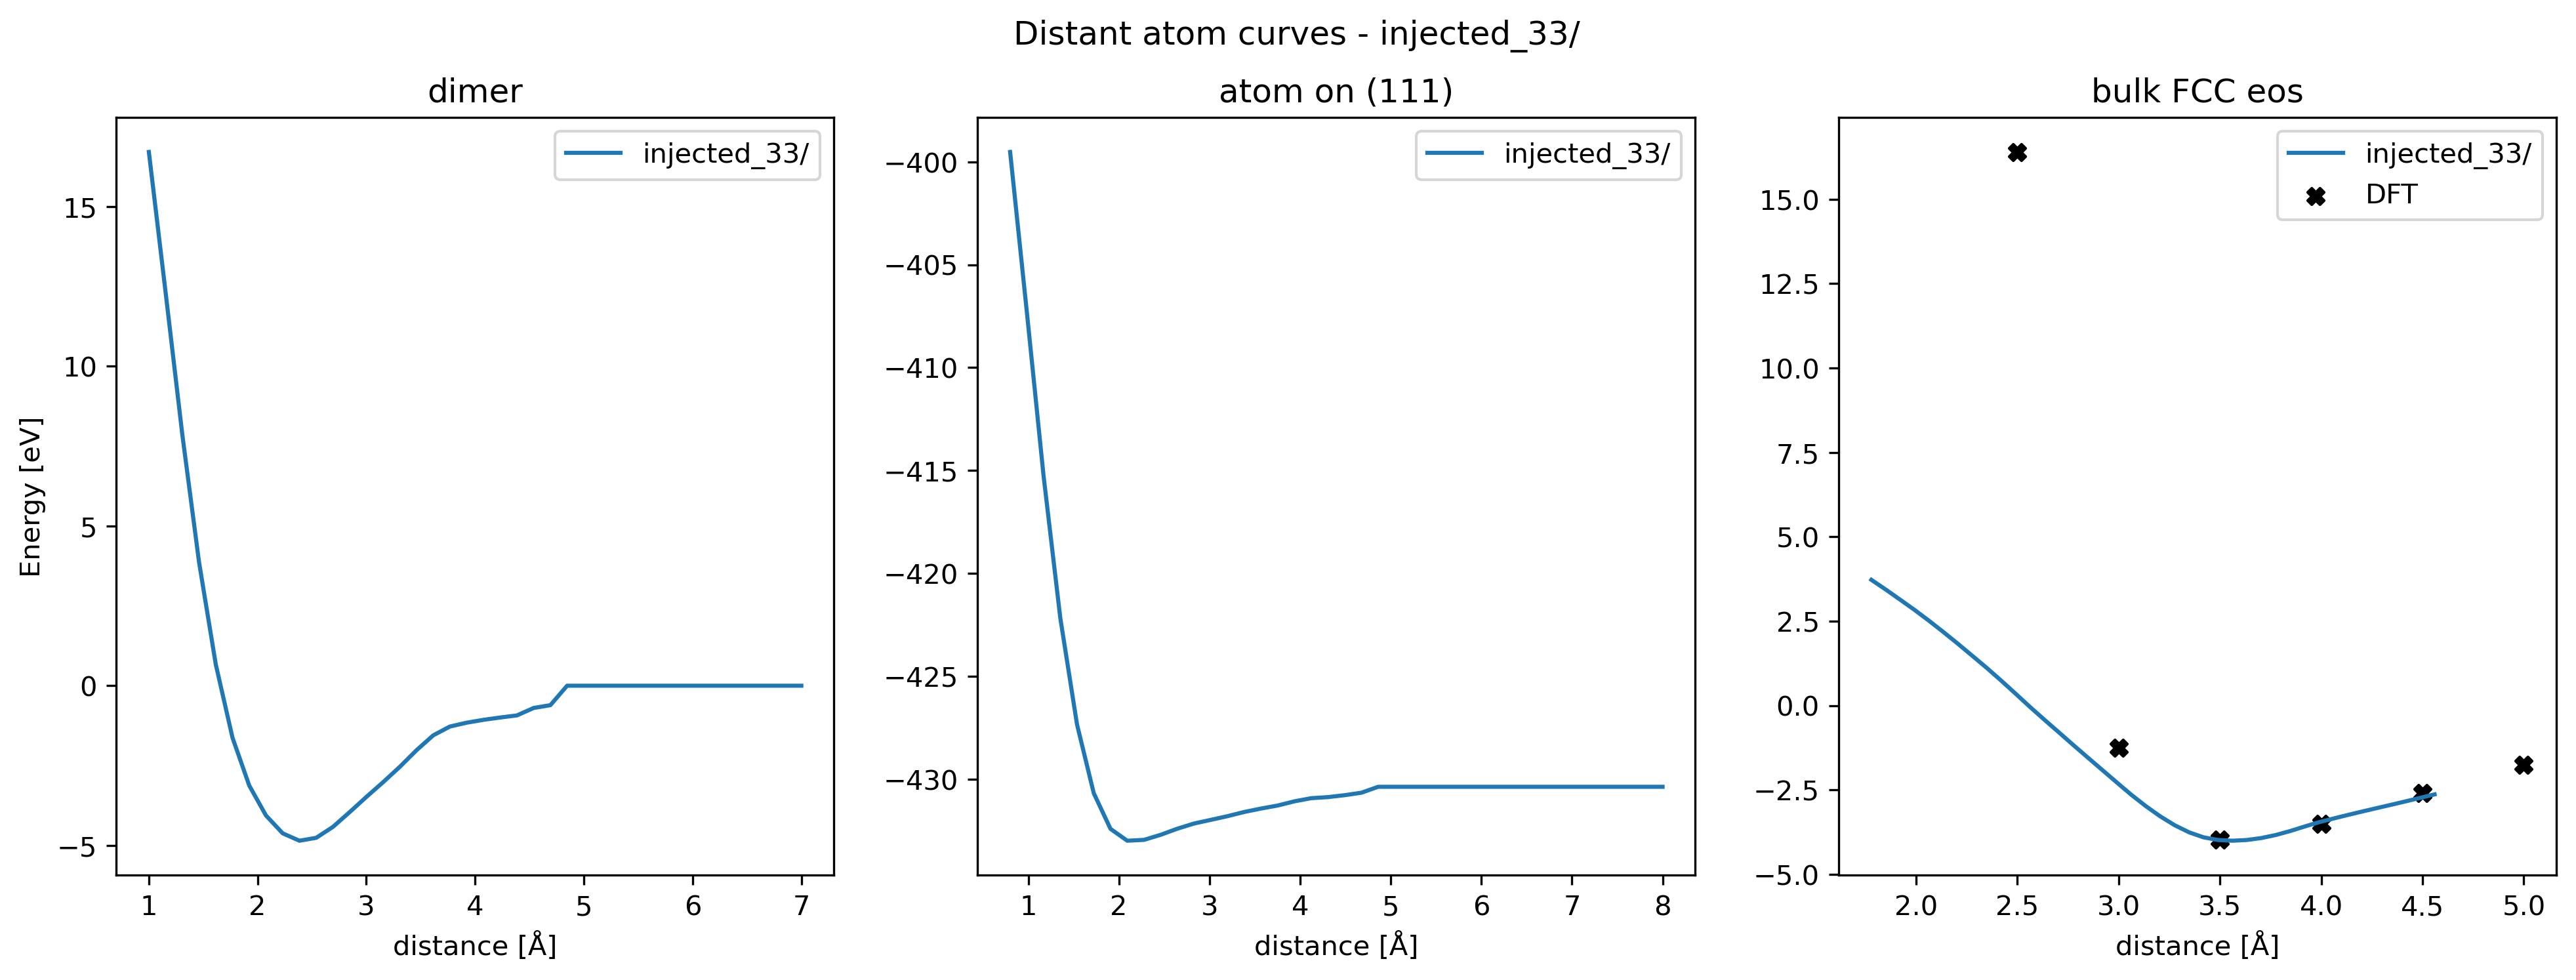

In [16]:
#plot far-atom energy curves
eos_large_ref = np.asarray([
    #[2.0, -1558.0512495920227],
    [2.5, -1645.04309947047],
    [3.0, -1662.685092877471],
    [3.5, -1665.4185483608774],
    [4.0, -1664.9515881903797],
    [4.5, -1664.0270273409217],
    [5.0, -1663.2001708360156]
])
E_iso = -1661.4439420703893

for fol, lab in zip(folders, folders):
    files  = [fol+'dimer_curve.dat', fol+'adsorbate_curve.dat', fol+'large_eos_curve.dat']
    colors = ['m', 'b', 'y']
    titles = ['dimer', 'atom on (111)', 'bulk FCC eos']
    fig, axs = plt.subplots(1, 3, figsize = (16,5), dpi=300)

    for f, a, c, t in zip(files, axs, colors, titles):
        data = np.loadtxt(f)
        if f==fol+'large_eos_curve.dat':
            data[:,1] = data[:,1]/4. #4 atoms per conv. cell

        if fol != "mace_copper_gpu/":
            a.plot(data[:,0], data[:,1], label=fol)
            a.legend()

        if f==fol+'large_eos_curve.dat':
            a.scatter(eos_large_ref[:,0], eos_large_ref[:,1]-E_iso, marker='X', color='k', label='DFT')    
            a.legend()
        a.set_xlabel('distance [Å]')
        a.set_title(t)

    axs[0].set_ylabel('Energy [eV]')
    plt.suptitle(f'Distant atom curves - {lab}')
plt.show()

## Clusters excess energy

Plotting the excess energy of several families of clusters as a function of the size. Here are considered Icosahedra (Ih), Decahedra (Dh), Octahedra (Oh), and regular truncated Octahedra (RTOh). Depending on the material, we might expect different regions of relative stability (specific clusters are favoured compared to other structures). The excess energy here is defined as

$$
\text{E.E.}=\frac{E-N\varepsilon_{coh}}{N^{2/3}}
$$
where $E$ is the energy of a configuration, $\varepsilon_{coh}$ is the cohesive energy of the chemical specie, and $N$ is the number of atoms in the cluster.

In [73]:
# ---- DFT reference values ----
from ase.io import read

ecoh = 4.000
eiso = -1661.4439420704

fol = '/Users/ginardi/Desktop/science/dft/DFT_xyz_45ry/'
names = ['ih55', 'ih147', 'oh55', 'oh147', 'dh55', 'dh147']
files = [fol+n+'.xyz' for n in names]

dft_results = {}
for n, f in zip(names, files):
    atoms = read(f)

    N = len(atoms)
    energy = atoms.get_potential_energy() - N*eiso
    excess_energy = (energy + ecoh*N) / (N**(2./3.))

    dft_results[n] = {}
    dft_results[n]['energy'] = float(energy)
    dft_results[n]['N'] = int(N)
    dft_results[n]['excess_energy'] = float( excess_energy )

In [74]:
def plot_hist_clusters_with_ref(filenames, conf_names, dft_results, ecoh):
    """
    For each configuration in conf_names, plots a histogram of the predicted
    excess energies from all files, with a vertical dotted red line marking
    the DFT reference value.

    Parameters:
        filenames  : list of yaml result files to read predictions from
        conf_names : list of configuration names (e.g. ['ih55', 'ih147', ...])
        dft_results: dictionary with DFT reference data (as built above)
        ecoh       : cohesive energy reference (eV), same as used for DFT
    """

    hist_data = [[] for _ in conf_names]

    for f in filenames:
        data = yaml.safe_load(open(f, 'r'))
        for i, n in enumerate(conf_names):
            # Read the predicted energy (total) for this config
            predicted_energy = data.get('special_configs').get(f'{n}.xyz').get('energy')
            N = dft_results[n]['N']
            # Compute excess energy the same way as for DFT
            predicted_excess = (predicted_energy + ecoh * N) / (N ** (2. / 3.))
            hist_data[i].append(predicted_excess)

    ncols = 3
    nrows = int(np.ceil(len(conf_names) / ncols))

    fig, axs = plt.subplots(nrows, ncols, figsize=(ncols * 3.0, nrows * 2.0))
    axs = axs.flatten()

    for i, name in enumerate(conf_names):

        # DFT reference excess energy for this config
        dft_ref = dft_results[name]['excess_energy']

        axs[i].hist(hist_data[i], bins=20, color='steelblue', edgecolor='white', alpha=0.8, label='Predicted')

        # Vertical dotted red line at DFT reference
        axs[i].axvline(x=dft_ref, color='red', linestyle='--', linewidth=1.5, label='DFT reference')

        axs[i].set_xlabel(r'Excess energy $[eV]$')
        axs[i].set_ylabel('Occurrence')
        axs[i].set_title(name)
        axs[i].legend(fontsize=8)

    # Hide unused subplots if conf_names is not a multiple of ncols
    for i in range(len(conf_names), len(axs)):
        axs[i].set_visible(False)

    plt.suptitle('Predicted excess energies vs DFT reference', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


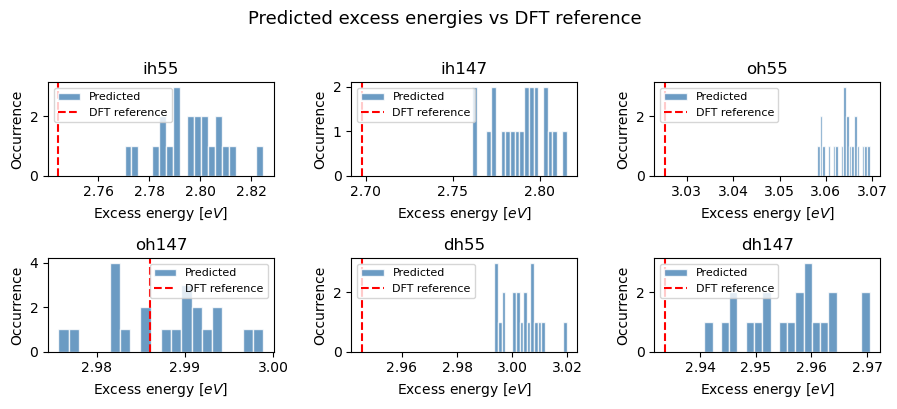

In [75]:
plot_hist_clusters_with_ref(full_names_r, names, dft_results, ecoh)

In [76]:
def plot_ee(folders, ref_values):


        ncols = 3
        nrows = math.ceil(len(folders) / ncols)

        fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows), dpi=300)
        axs = np.array(axs).reshape(-1)  # flatten safely

        for idx, fol in enumerate(folders):
                ax = axs[idx]

                files  = ['ico-exc.dat', 'mdh-exc.dat', 'oh-exc.dat', 'rto-exc.dat']
                colors = ['b', 'tab:orange', 'm', 'r']
                labels = ['Ih', 'Dh', 'Oh', 'RTOh']
                shapes = ['s', 'o', 'v', '*']

                data = []
                valid_labels = []
                valid_colors = []
                valid_shapes = []

                for f, l, c, s in zip(files, labels, colors, shapes):

                        try:
                                d = np.loadtxt(fol + f)
                                data.append(d)
                                valid_labels.append(l)
                                valid_colors.append(c)
                                valid_shapes.append(s)

                        except FileNotFoundError:
                                print(f"Warning: File '{f}' not found in {fol}. Skipping...")

                        if not data:
                                print(f"Warning: No data files found for folder '{fol}'.")
                                ax.set_visible(False)
                                continue

                for d, l, c, s in zip(data, valid_labels, valid_colors, valid_shapes):
                        ax.scatter(d[:,0], d[:,2], label=l, color=c, marker=s)

                ax.set_xscale('log')
                ax.set_xlabel('N')
                ax.set_ylabel('excess energy [eV]')
                ax.set_ylim(2.4, 3.15)
                ax.set_title(fol)
                ax.legend(fontsize=8)

                # ---- DFT reference points ----
                # ax.plot([38], [ee_rto38], color=colors[3], marker=shapes[3],
                #         markeredgewidth=1.5, markeredgecolor='k')
                ax.plot([55], [ref_values['ih55']['excess_energy']], color=colors[0], marker=shapes[0],
                        markeredgewidth=1.5, markeredgecolor='k')
                ax.plot([55], [ref_values['dh55']['excess_energy']], color=colors[1], marker=shapes[1],
                        markeredgewidth=1.5, markeredgecolor='k')
                ax.plot([55], [ref_values['oh55']['excess_energy']], color=colors[2], marker=shapes[2],
                        markeredgewidth=1.5, markeredgecolor='k')
                ax.plot([147], [ref_values['ih147']['excess_energy']], color=colors[0], marker=shapes[0],
                        markeredgewidth=1.5, markeredgecolor='k')
                ax.plot([147], [ref_values['dh147']['excess_energy']], color=colors[1], marker=shapes[1],
                        markeredgewidth=1.5, markeredgecolor='k')
                ax.plot([147], [ref_values['oh147']['excess_energy']], color=colors[2], marker=shapes[2],
                        markeredgewidth=1.5, markeredgecolor='k')

        # Hide unused subplots
        for j in range(len(folders), len(axs)):
                axs[j].set_visible(False)

        plt.tight_layout()


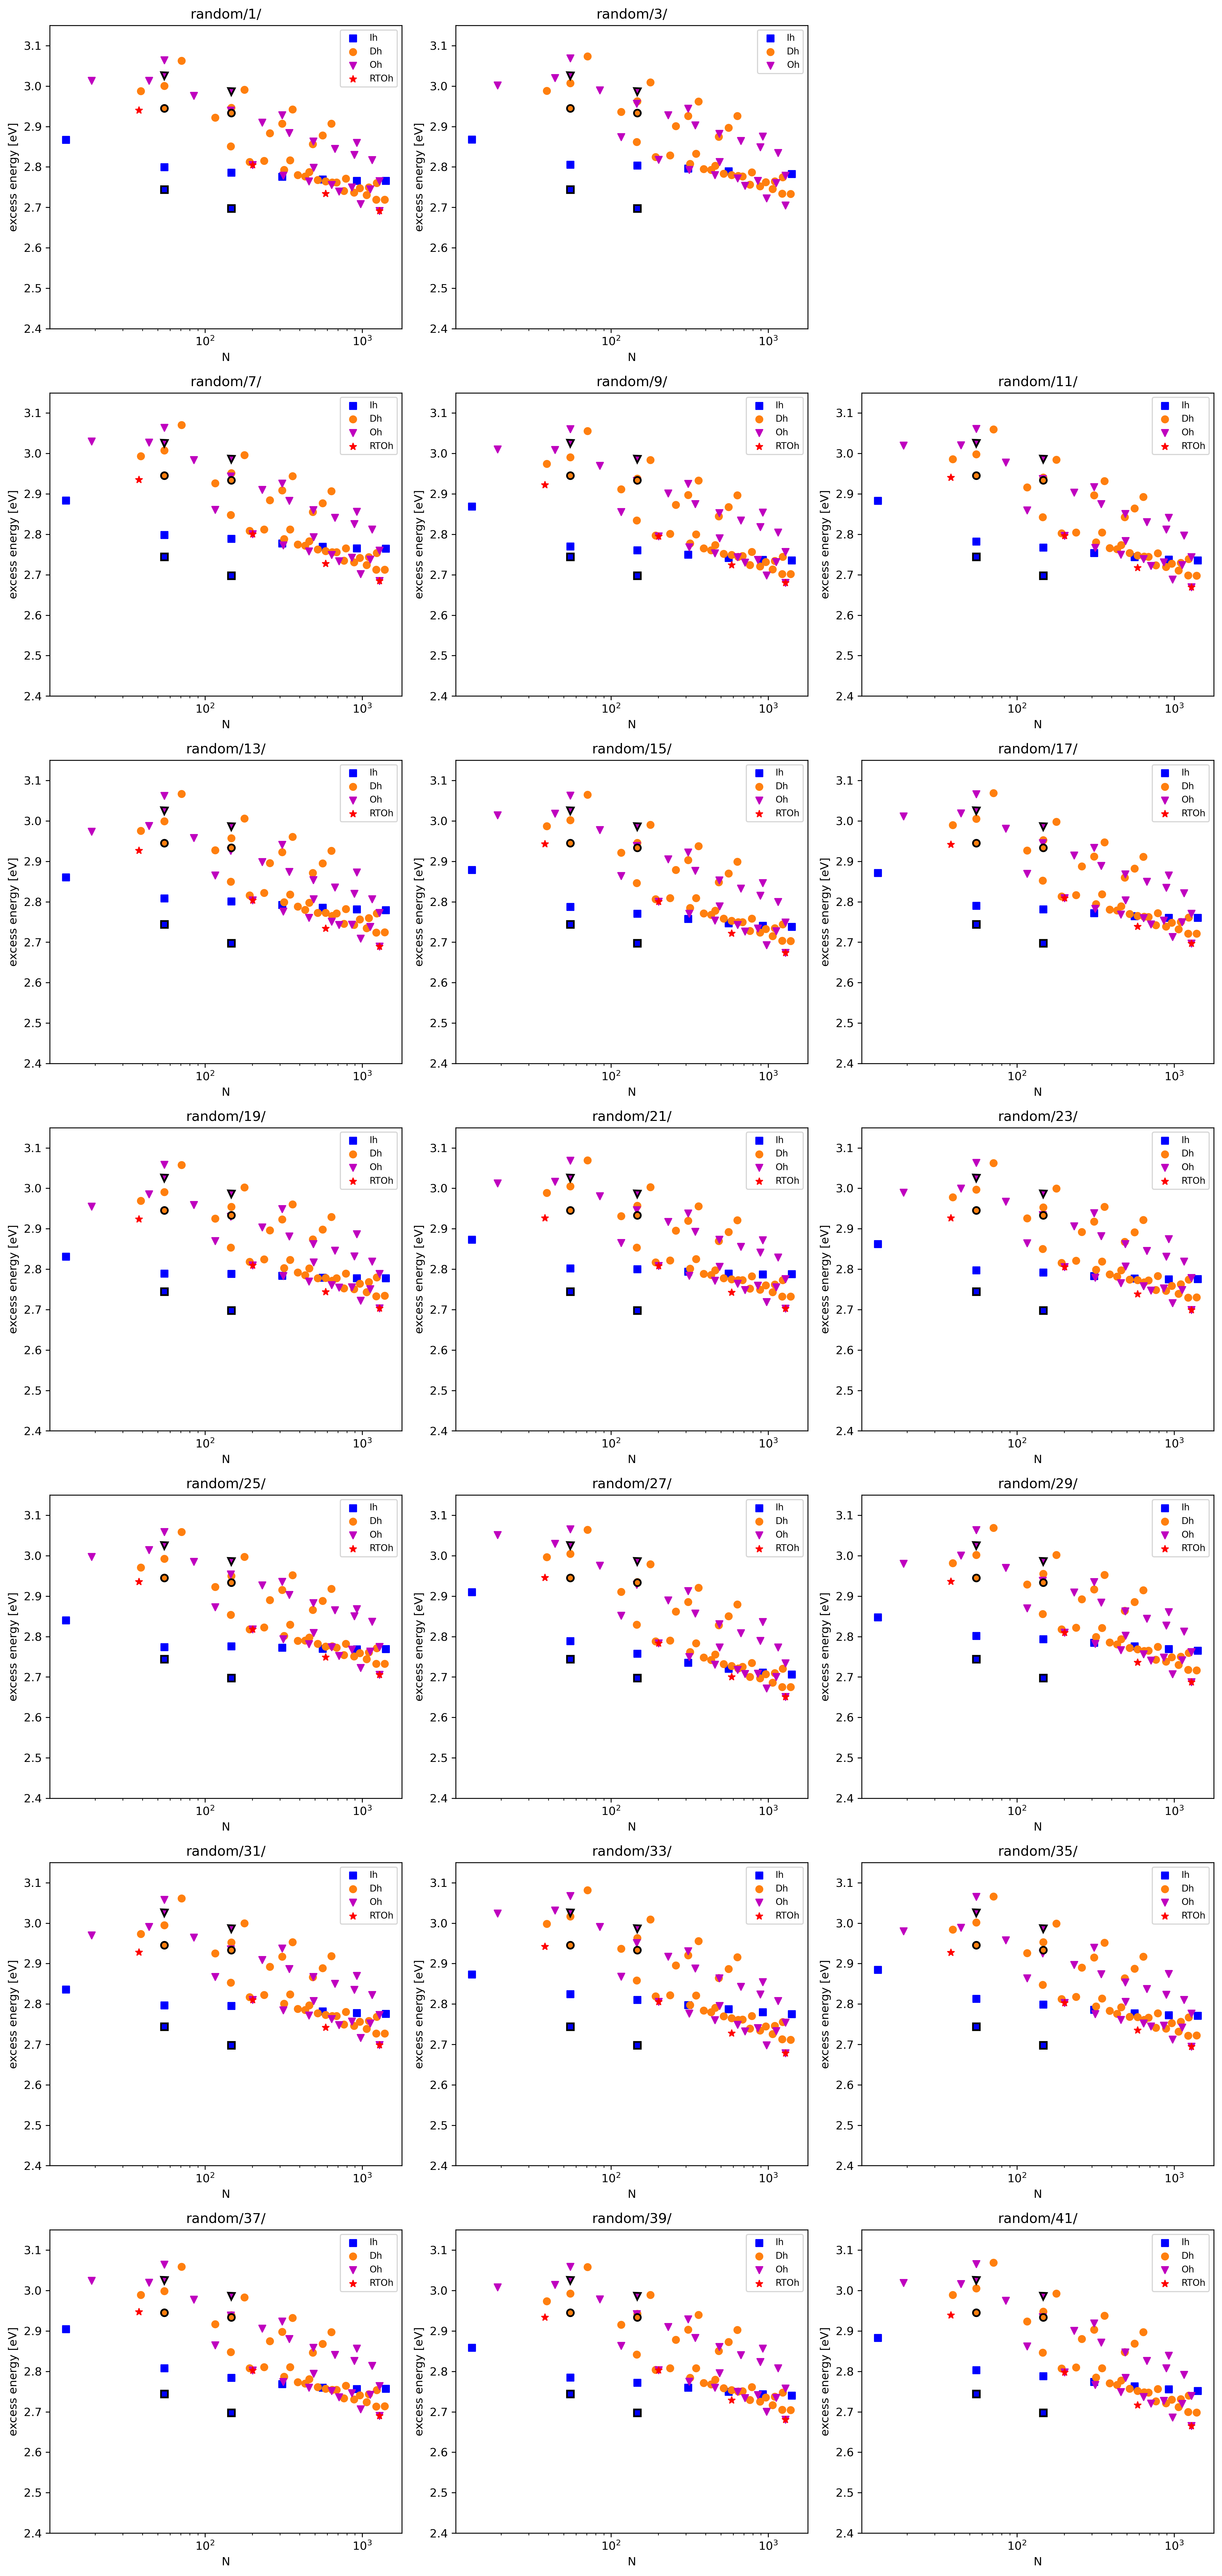

In [78]:
plot_ee(folders_r, dft_results)

/var/folders/rn/d8rdqv991jv59x3n1xfww9dc0000gn/T/ipykernel_77732/1007815892.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)
/var/folders/rn/d8rdqv991jv59x3n1xfww9dc0000gn/T/ipykernel_77732/1007815892.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


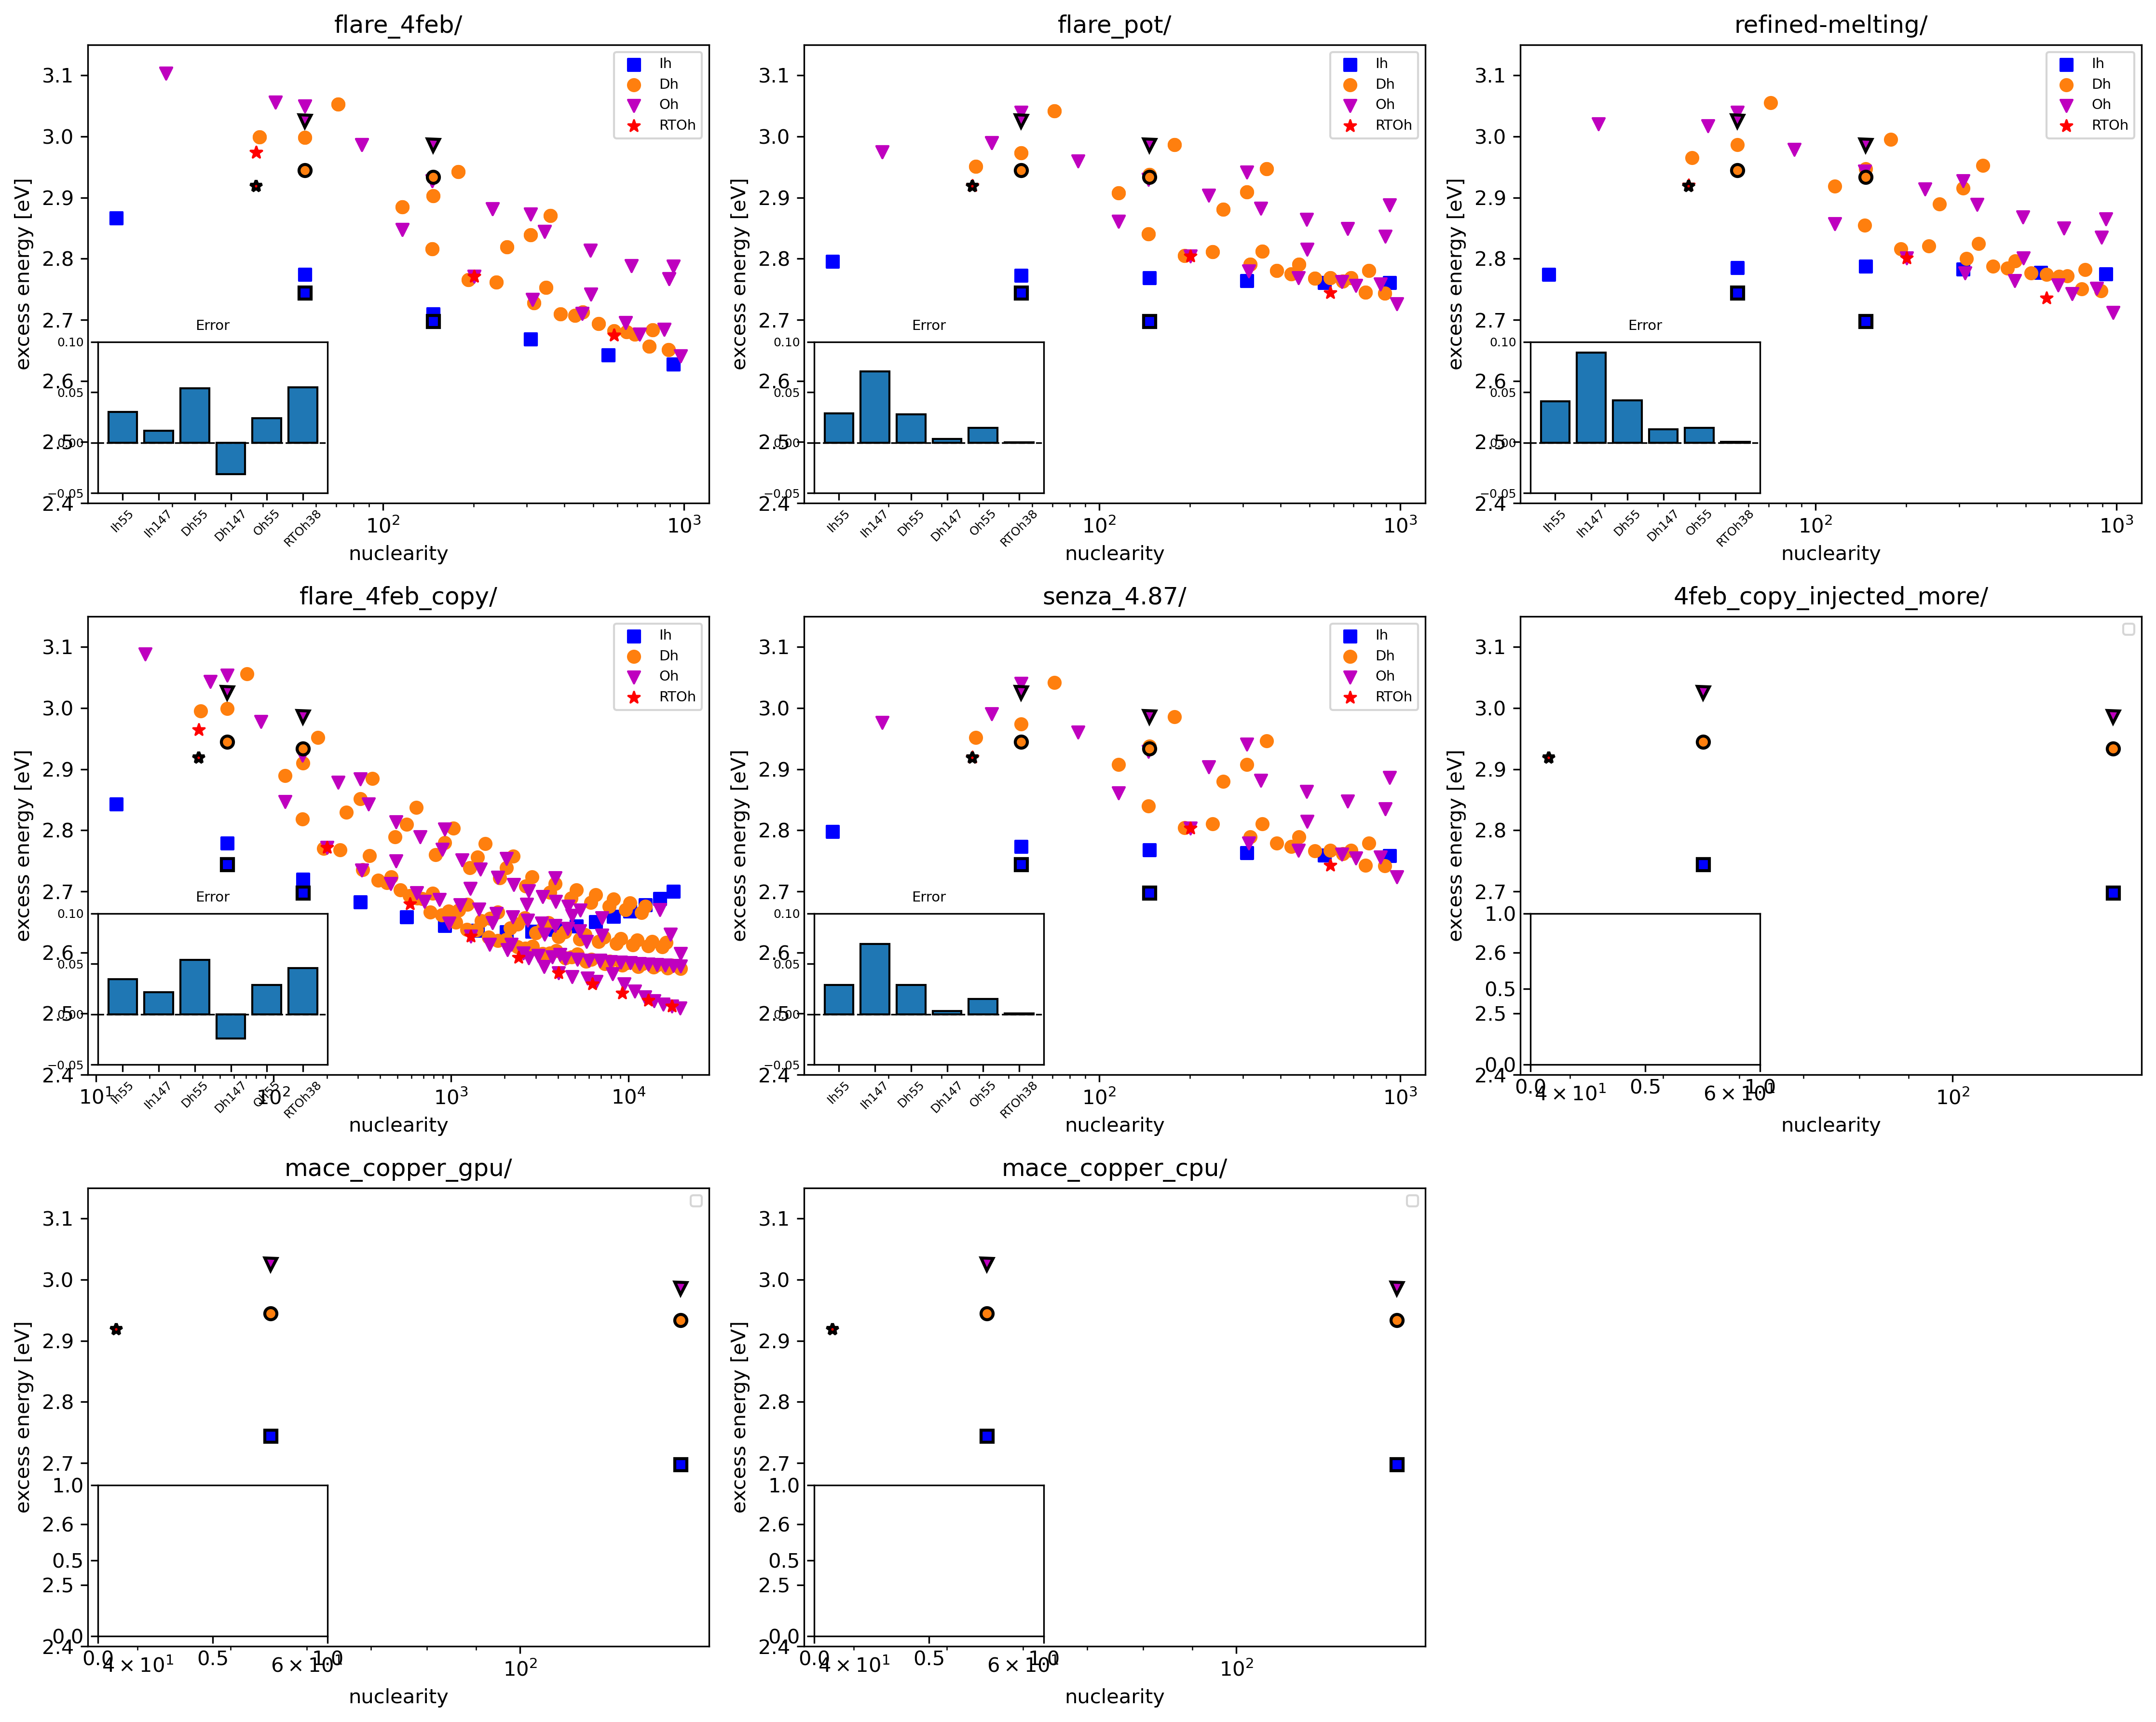

In [338]:
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---- DFT reference values ----
dft_values = {
    'Ih55': 2.744,
    'Ih147': 2.698,
    'Dh55': 2.945,
    'Dh147': 2.934,
    'Oh55': 3.025,
    'Oh147': 2.986,
    'RTOh38': 2.919
}

file_info = {
    'ico-exc.dat': ('Ih', [55, 147]),
    'mdh-exc.dat': ('Dh', [55, 147]),
    'oh-exc.dat': ('Oh', [55, 147]),
    'rto-exc.dat': ('RTOh', [38])
}

ncols = 3
nrows = math.ceil(len(folders) / ncols)

fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), dpi=300)
axs = np.array(axs).reshape(-1)

for idx, fol in enumerate(folders):
    ax = axs[idx]

    colors = ['b', 'tab:orange', 'm', 'r']
    shapes = ['s', 'o', 'v', '*']

    predictions = {}

    # ---- Main scatter plot ----
    for (filename, (label, sizes)), color, marker in zip(file_info.items(), colors, shapes):

        try:
            data = np.loadtxt(fol + filename)

            if fol == 'mace_copper/':
                ycol = 1
            else:
                ycol = 2

            ax.scatter(data[:,0], data[:,ycol],
                       label=label,
                       color=color,
                       marker=marker)

            # collect prediction for error inset
            for size in sizes:
                key = f"{label}{size}"
                idx_size = np.where(np.isclose(data[:,0], size))[0]
                if len(idx_size) > 0:
                    predictions[key] = data[idx_size[0], ycol]

        except FileNotFoundError:
            print(f"Warning: {filename} not found in {fol}")

    ax.set_xscale('log')
    ax.set_ylim(2.4, 3.15)
    ax.set_xlabel('nuclearity')
    ax.set_ylabel('excess energy [eV]')
    ax.set_title(fol)
    ax.legend(fontsize=7)

    # ---- DFT markers on main plot ----
    for key, val in dft_values.items():
        size = int(''.join(filter(str.isdigit, key)))
        label = ''.join(filter(str.isalpha, key))

        color_map = {'Ih':'b', 'Dh':'tab:orange', 'Oh':'m', 'RTOh':'r'}
        marker_map = {'Ih':'s', 'Dh':'o', 'Oh':'v', 'RTOh':'*'}

        ax.plot([size], [val],
                marker=marker_map[label],
                color=color_map[label],
                markeredgewidth=1.5,
                markeredgecolor='k')

    # ---- Inset error plot ----
    inset = inset_axes(ax, width="37%", height="33%", loc='lower left')

    structures = []
    errors = []

    for key in dft_values:
        if key in predictions:
            structures.append(key)
            errors.append(predictions[key] - dft_values[key])

    if errors:
        x = np.arange(len(structures))
        inset.bar(x, errors, edgecolor='black')
        inset.axhline(0, color='black', linestyle='--', linewidth=0.8)
        inset.set_xticks(x)
        inset.set_xticklabels(structures, rotation=45, fontsize=6)
        inset.tick_params(axis='y', labelsize=6)
        inset.set_title("Error", fontsize=7)
        inset.set_ylim(-0.05, 0.1)

# Hide unused axes
for j in range(len(folders), len(axs)):
    axs[j].set_visible(False)

plt.tight_layout()
plt.show()


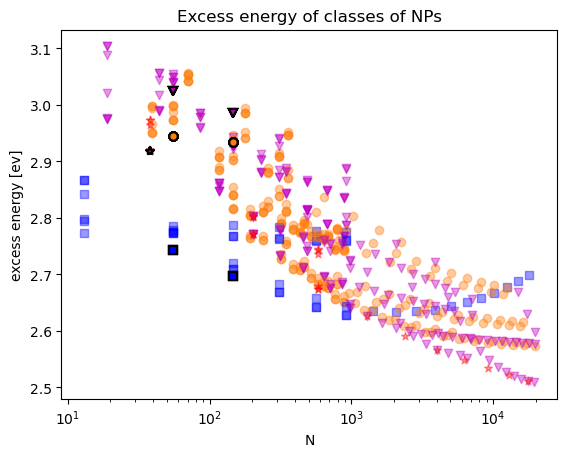

In [339]:
#unique plot for comparison
plt.figure()
for fol in folders:
    if fol != "mace_copper/":
    #fol = "mace_copper/"
    #files  = [fol+'ico-exc.dat',  fol+'octa-exc.dat', fol+'deca-exc.dat'] #, fol+'deca-exc.dat'
    #colors = ['b', 'y', 'r']
    #labels = ['ico', 'deca', 'octa']
        files  = ['ico-exc.dat', 'mdh-exc.dat', 'oh-exc.dat', 'rto-exc.dat']
        colors = ['b', 'tab:orange', 'm', 'r']
        labels = ['Ih', 'Dh', 'Oh', 'RTOh']
        shapes = ['s', 'o', 'v', '*']

        data  = []
        valid_labels = []
        valid_colors = []
        
        for f, l, c in zip(files, labels, colors):
            try:
                data.append(np.loadtxt(fol+f))
                valid_labels.append(l)
                valid_colors.append(c)
            except FileNotFoundError:
                print(f"Warning: File '{f}' not found in {fol}. Skipping...")

        # Only create plot if we have data
        if data:
            for d, l, c, s in zip(data, valid_labels, valid_colors, shapes):
                plt.scatter(d[:,0], d[:,2], color=c, marker=s, alpha=0.4)

    plt.xscale('log')
    plt.xlabel('N')
    plt.ylabel('excess energy [ev]')
    #plt.ylim(2.4, 3.15)
    plt.title(f'Excess energy of classes of NPs')
    #plt.legend()

    #plot dft data
    plt.plot([38], [ee_rto38], color=colors[3], marker=shapes[3], markeredgewidth=1.5, markeredgecolor='k')
    plt.plot([55], [ee_ih55], color=colors[0], marker=shapes[0], markeredgewidth=1.5, markeredgecolor='k')
    plt.plot([55], [ee_dh55], color=colors[1], marker=shapes[1], markeredgewidth=1.5, markeredgecolor='k')
    plt.plot([55], [ee_oh55], color=colors[2], marker=shapes[2], markeredgewidth=1.5, markeredgecolor='k')
    plt.plot([147], [ee_ih147], color=colors[0], marker=shapes[0], markeredgewidth=1.5, markeredgecolor='k')
    plt.plot([147], [ee_dh147], color=colors[1], marker=shapes[1], markeredgewidth=1.5, markeredgecolor='k')
    plt.plot([147], [ee_oh147], color=colors[2], marker=shapes[2], markeredgewidth=1.5, markeredgecolor='k')


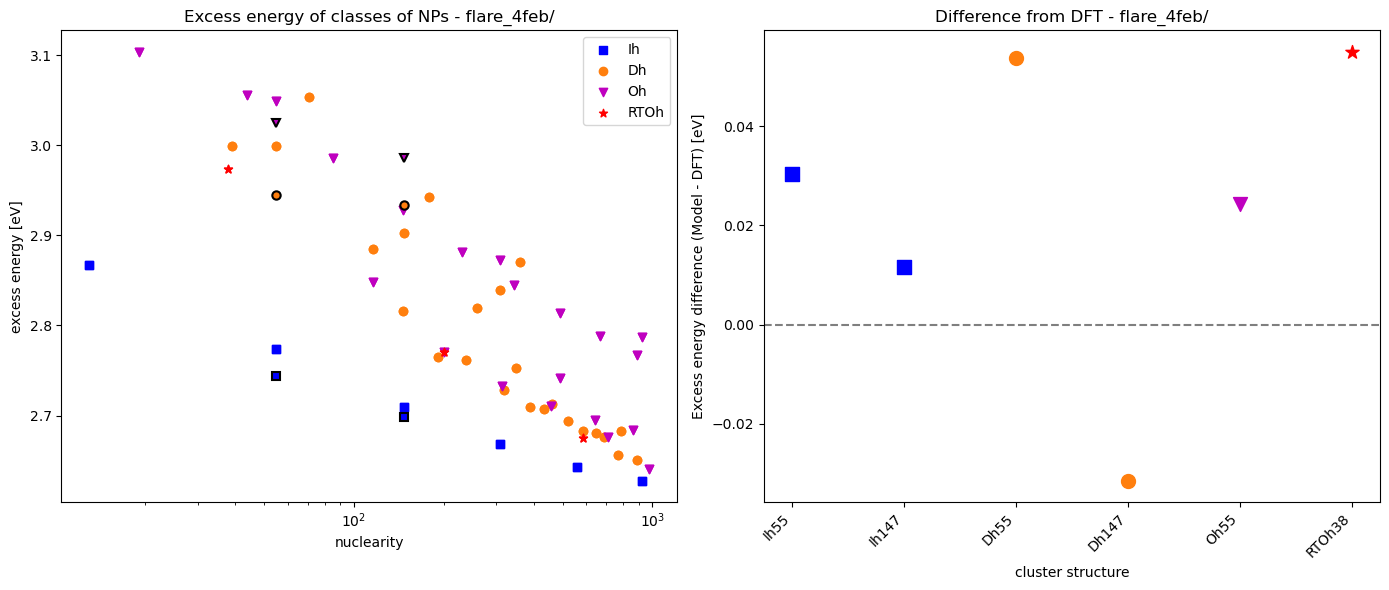

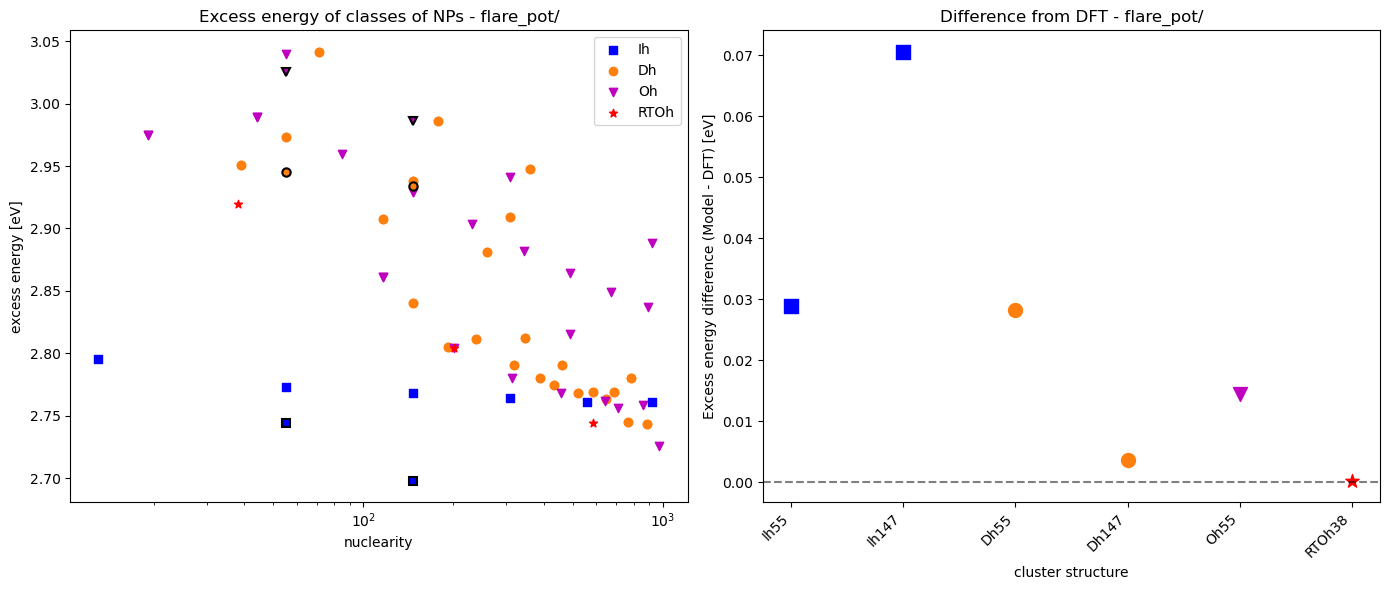

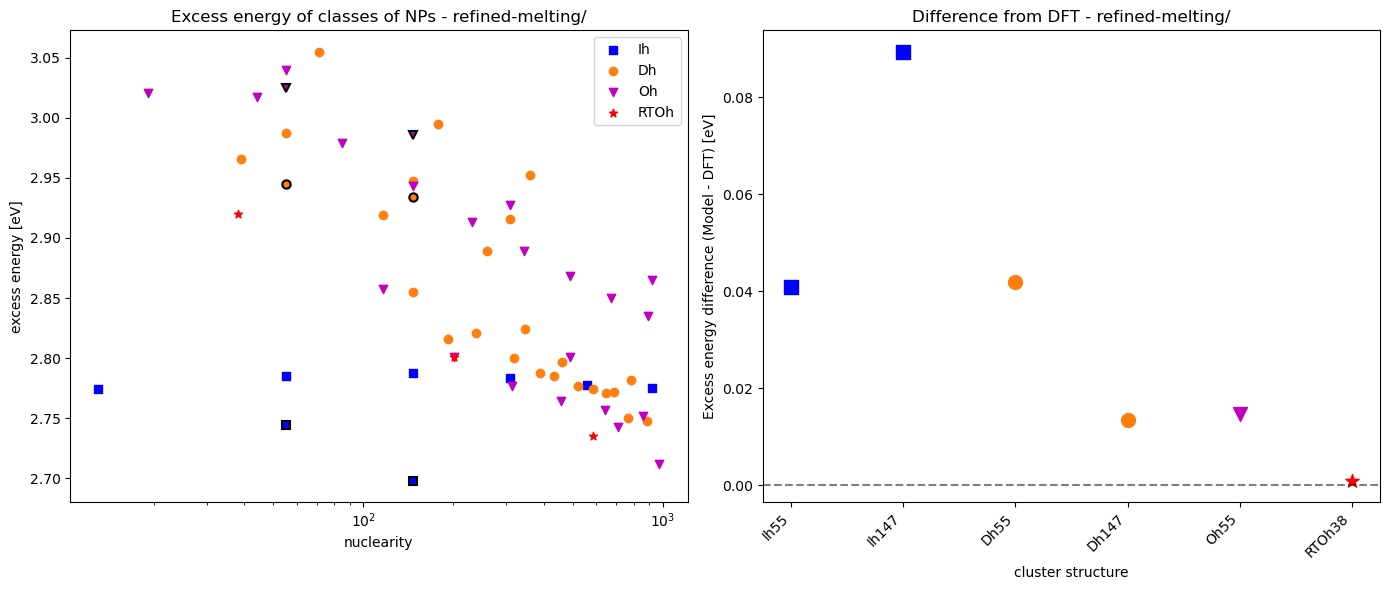

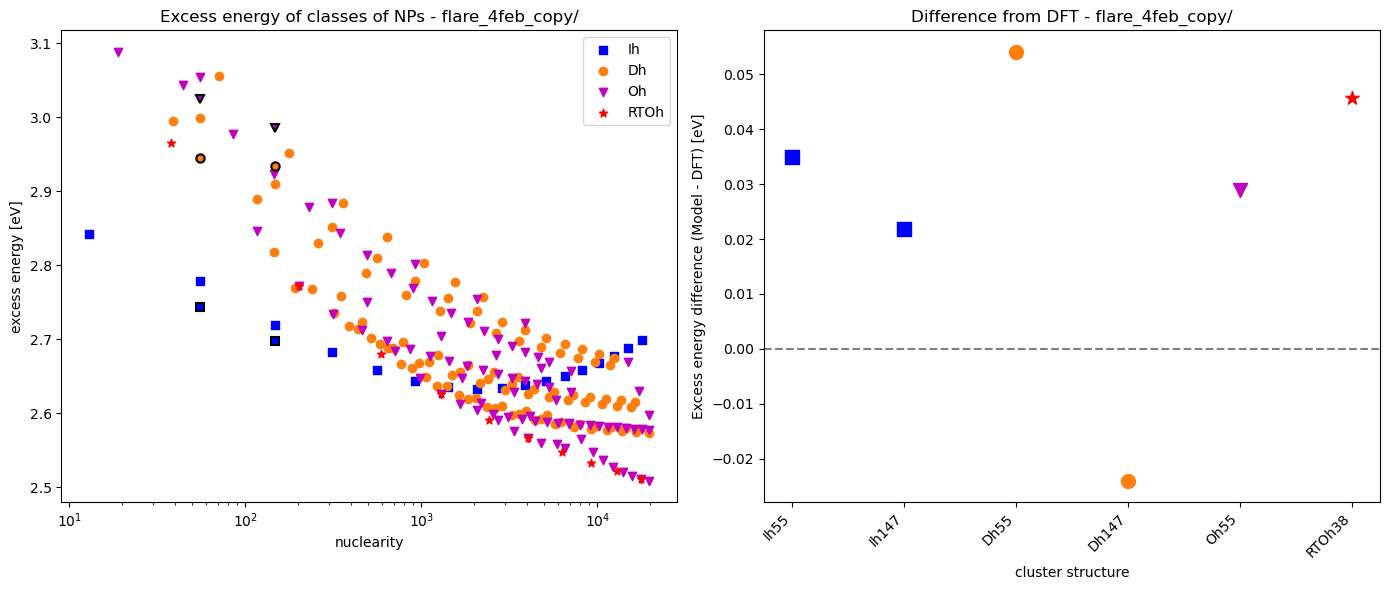

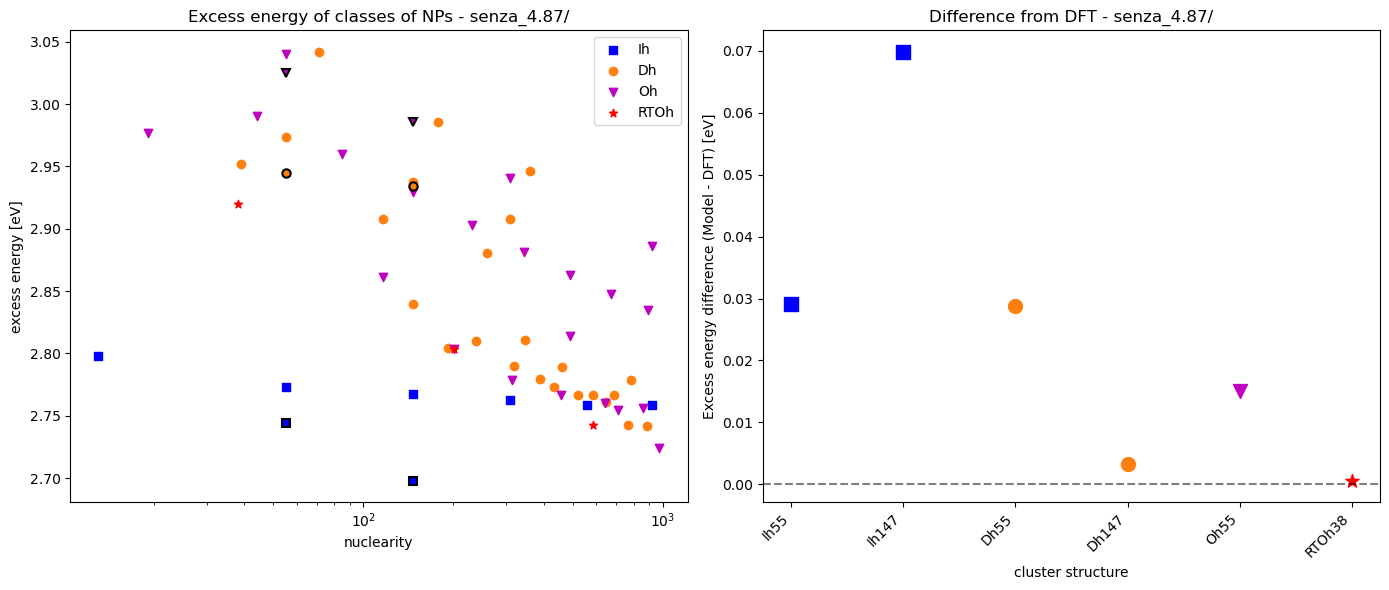

In [340]:
#plot excess energy
#dft values here
ee_ih55 = 2.744
ee_ih147 = 2.698
ee_dh55 = 2.945 
ee_dh147 = 2.934 
ee_oh55 = 3.025 
ee_oh147 = 2.986
ee_rto38 = 2.919 

# Store DFT values in a dictionary for easy lookup
dft_values = {
    'Ih': {55: ee_ih55, 147: ee_ih147},
    'Dh': {55: ee_dh55, 147: ee_dh147},
    'Oh': {55: ee_oh55, 147: ee_oh147},
    'RTOh': {38: ee_rto38}
}

for fol in folders:
    files  = ['ico-exc.dat', 'mdh-exc.dat', 'oh-exc.dat', 'rto-exc.dat']
    colors = ['b', 'tab:orange', 'm', 'r']
    labels = ['Ih', 'Dh', 'Oh', 'RTOh']
    shapes = ['s', 'o', 'v', '*']

    data  = []
    valid_labels = []
    valid_colors = []
    valid_shapes = []
    
    for f, l, c, s in zip(files, labels, colors, shapes):
        try:
            data.append(np.loadtxt(fol+f))
            valid_labels.append(l)
            valid_colors.append(c)
            valid_shapes.append(s)
        except FileNotFoundError:
            print(f"Warning: File '{f}' not found in {fol}. Skipping...")

    # Only create plot if we have data
    if data:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        
        # LEFT SUBPLOT - existing excess energy plot
        for d, l, c, s in zip(data, valid_labels, valid_colors, valid_shapes):
            if fol == 'mace_copper/':
                ax1.scatter(d[:,0], d[:,1], label=l, color=c, marker=s)
            else:
                ax1.scatter(d[:,0], d[:,2], label=l, color=c, marker=s)
        
        ax1.set_xscale('log')
        ax1.set_xlabel('nuclearity')
        ax1.set_ylabel('excess energy [eV]')
        ax1.set_title(f'Excess energy of classes of NPs - {fol}')
        ax1.legend()

        # Plot DFT data on left subplot
        ax1.plot([55], [ee_ih55], color=colors[0], marker=shapes[0], markeredgewidth=1.5, markeredgecolor='k')
        ax1.plot([55], [ee_dh55], color=colors[1], marker=shapes[1], markeredgewidth=1.5, markeredgecolor='k')
        ax1.plot([55], [ee_oh55], color=colors[2], marker=shapes[2], markeredgewidth=1.5, markeredgecolor='k')
        ax1.plot([147], [ee_ih147], color=colors[0], marker=shapes[0], markeredgewidth=1.5, markeredgecolor='k')
        ax1.plot([147], [ee_dh147], color=colors[1], marker=shapes[1], markeredgewidth=1.5, markeredgecolor='k')
        ax1.plot([147], [ee_oh147], color=colors[2], marker=shapes[2], markeredgewidth=1.5, markeredgecolor='k')

        # RIGHT SUBPLOT - difference from DFT with categorical labels
        x_positions = []
        x_labels = []
        diff_values = []
        bar_colors = []
        bar_shapes = []
        
        pos = 0
        for d, l, c, s in zip(data, valid_labels, valid_colors, valid_shapes):
            if l in dft_values:
                sizes_to_check = sorted(dft_values[l].keys())
                
                for size in sizes_to_check:
                    # Find the row where the first column (size) matches
                    idx = np.where(d[:,0] == size)[0]
                    if len(idx) > 0:
                        if fol == 'mace_copper/':
                            model_value = d[idx[0], 1]
                        else:
                            model_value = d[idx[0], 2]
                        dft_value = dft_values[l][size]
                        diff = model_value - dft_value
                        
                        x_positions.append(pos)
                        x_labels.append(f"{l}{size}")
                        diff_values.append(diff)
                        bar_colors.append(c)
                        bar_shapes.append(s)
                        pos += 1
        
        # Plot points with categorical x-axis
        for xp, yv, c, s in zip(x_positions, diff_values, bar_colors, bar_shapes):
            ax2.scatter(xp, yv, color=c, marker=s, s=100)
        
        ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        ax2.set_xticks(x_positions)
        ax2.set_xticklabels(x_labels, rotation=45, ha='right')
        ax2.set_xlabel('cluster structure')
        ax2.set_ylabel('Excess energy difference (Model - DFT) [eV]')
        ax2.set_title(f'Difference from DFT - {fol}')
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"Warning: No data files found for folder '{fol}'. Skipping plot...")

TBAdded: whats in the database, MD performance

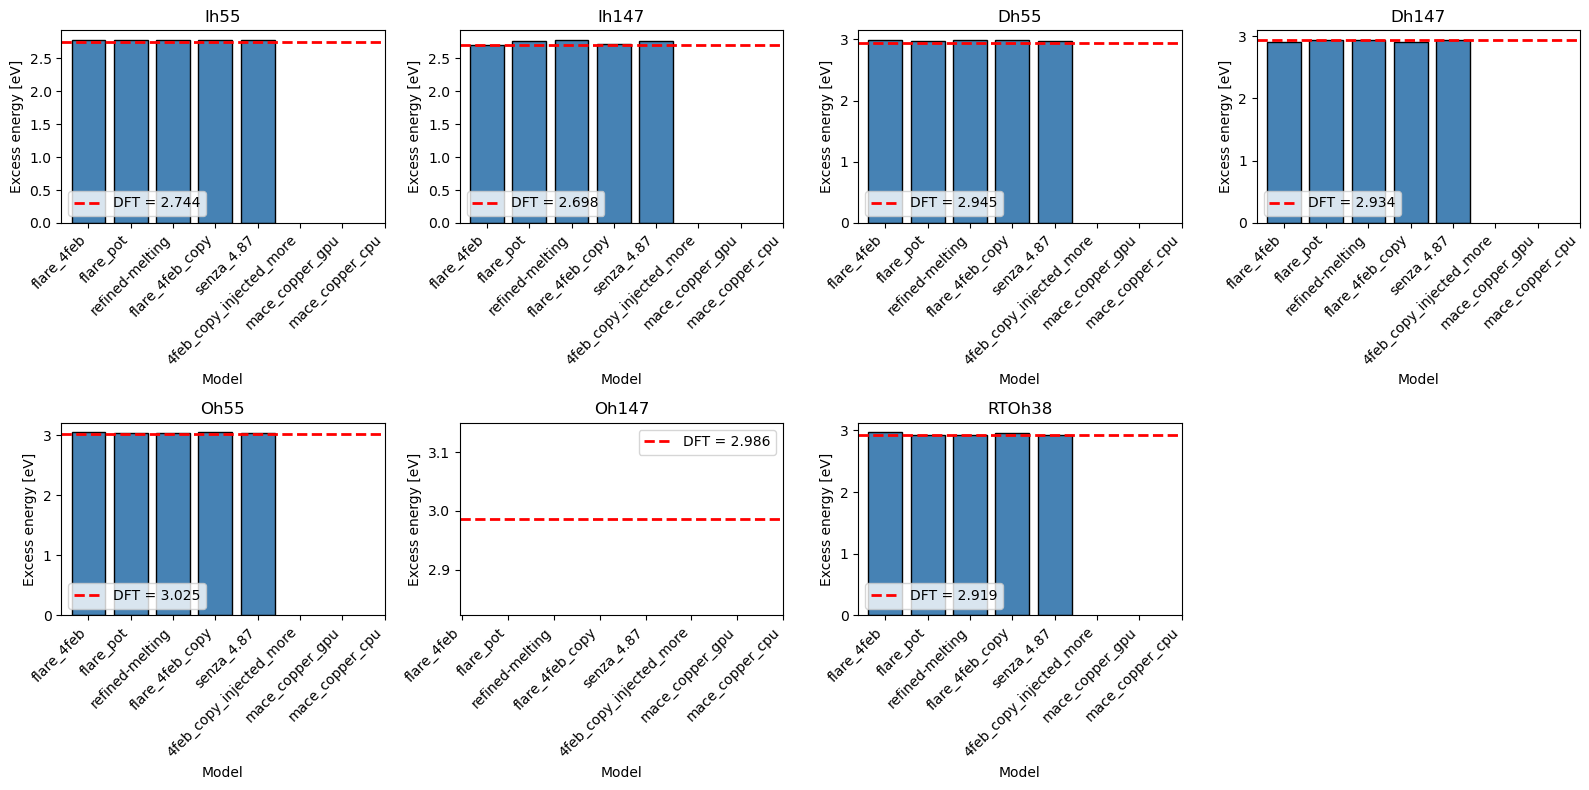

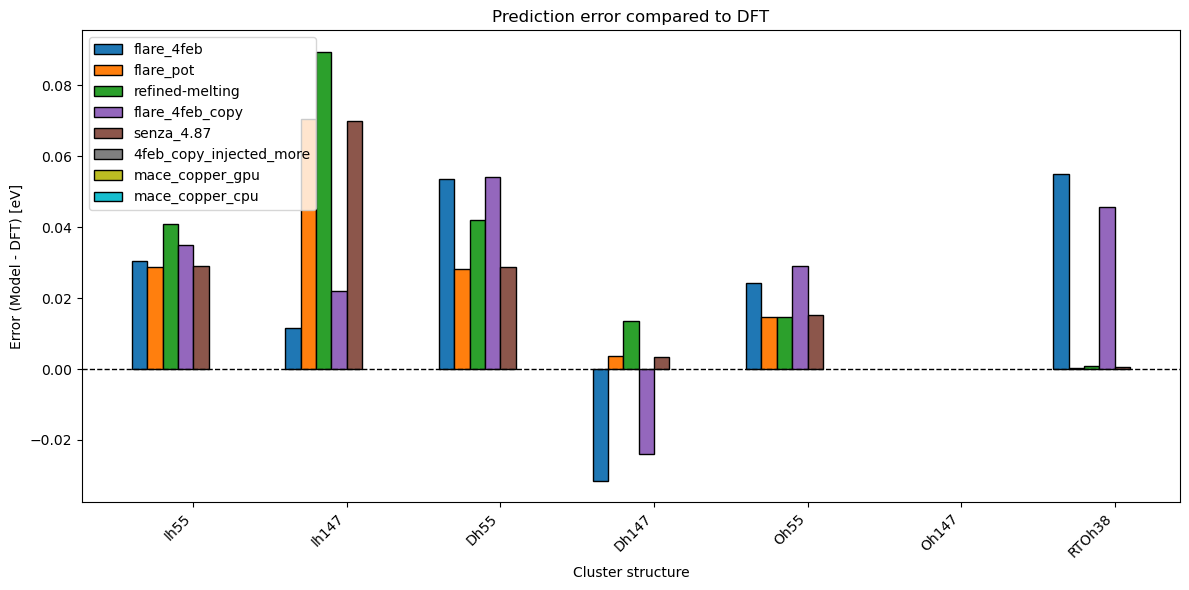

In [341]:
import numpy as np
import matplotlib.pyplot as plt

# DFT reference values
dft_values = {
    'Ih55': 2.744,
    'Ih147': 2.698,
    'Dh55': 2.945,
    'Dh147': 2.934,
    'Oh55': 3.025,
    'Oh147': 2.986,
    'RTOh38': 2.919
}

# Map file names to labels and sizes
file_info = {
    'ico-exc.dat': ('Ih', [55, 147]),
    'mdh-exc.dat': ('Dh', [55, 147]),
    'oh-exc.dat': ('Oh', [55, 147]),
    'rto-exc.dat': ('RTOh', [38])
}

# Define your folders here
#folders    = ["flare_pot/", "refined-melting/", "flare_4feb_copy/", "flare_9feb_1/", "flare_9feb_2/", "flare_9feb_4/", "flare_9feb_5/", "flare_9feb_7/"]

# Collect predictions for each structure
predictions = {key: [] for key in dft_values.keys()}
folder_labels = []

for fol in folders:
    folder_labels.append(fol.rstrip('/'))
    
    for filename, (label, sizes) in file_info.items():
        try:
            data = np.loadtxt(fol + filename)
            
            for size in sizes:
                key = f"{label}{size}"
                idx = np.where(np.isclose(data[:,0], size))[0]
                
                if len(idx) > 0:
                    # Adjust column index based on folder if needed
                    if fol == 'mace_copper/':
                        value = data[idx[0], 1]
                    else:
                        value = data[idx[0], 2]
                    predictions[key].append(value)
                else:
                    predictions[key].append(np.nan)
                    
        except FileNotFoundError:
            print(f"Warning: File '{filename}' not found in {fol}. Skipping...")
            for size in sizes:
                key = f"{label}{size}"
                predictions[key].append(np.nan)

# ============================================================
# PLOT 1: Grouped bar chart for each structure
# ============================================================
structures = list(dft_values.keys())
x = np.arange(len(folder_labels))
width = 0.8

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, struct in enumerate(structures):
    ax = axes[i]
    values = predictions[struct]
    dft = dft_values[struct]
    
    # Plot bars for each folder
    bars = ax.bar(x, values, width, color='steelblue', edgecolor='black')
    
    # Plot DFT reference as horizontal dotted line
    ax.axhline(y=dft, color='red', linestyle='--', linewidth=2, label=f'DFT = {dft:.3f}')
    
    ax.set_xlabel('Model')
    ax.set_ylabel('Excess energy [eV]')
    ax.set_title(struct)
    ax.set_xticks(x)
    ax.set_xticklabels(folder_labels, rotation=45, ha='right')
    ax.legend()

# Hide unused subplot
if len(structures) < len(axes):
    for j in range(len(structures), len(axes)):
        axes[j].axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: Difference from DFT (error) for each folder
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(structures))
width = 0.8 / len(folder_labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(folder_labels)))

for i, (fol, color) in enumerate(zip(folder_labels, colors)):
    errors = []
    for struct in structures:
        if not np.isnan(predictions[struct][i]):
            errors.append(predictions[struct][i] - dft_values[struct])
        else:
            errors.append(np.nan)
    
    offset = (i - len(folder_labels)/2 + 0.5) * width
    ax.bar(x + offset, errors, width, label=fol, color=color, edgecolor='black')

ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Cluster structure')
ax.set_ylabel('Error (Model - DFT) [eV]')
ax.set_title('Prediction error compared to DFT')
ax.set_xticks(x)
ax.set_xticklabels(structures, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()